# Retrieval Grader

### Retrieval Grader: An LLM-based evaluator that examines the user's question and the documents retrieved by ChromaDB, and determines whether the retrieved content is relevant enough to be used for answer generation.

                User Question
                       ↓
                  ChromaDB
                       ↓
                 Top-k Documents
                       ↓
               ┌───────────────┐
               │ Retrieval     │             Overall flow of project
               │    Grader     │
               └───────┬───────┘
                       ↓
                 Relevant?
                  ↙       ↘
                YES        NO
                 ↓          ↓
             Generate    Rewrite Query
                           ↓
                       Web Search

In [1]:
# This state will travel through our LangGraph workflow.

# We are now defining the information that our actual VeriRAG system needs.

# Later we will add more fields such as:
# - rewritten_query
# - web_results
# - answer
# - hallucination_check
# For now, we focus on retrieval grading.

from typing import TypedDict
from langchain_core.documents import Document


class GraphState(TypedDict):

    # The original question asked by the user.
    question: str

    # Documents retrieved from ChromaDB.
    documents: list[Document]

    # Whether the retrieved documents are relevant.
    # This will be produced by our grader.
    relevant: bool


print("VeriRAG GraphState created successfully.")

VeriRAG GraphState created successfully.


In [2]:
# This node performs the RETRIEVAL step.
#
# It takes the user's question and searches our
# existing ChromaDB for the most relevant chunks.

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma


# Load the SAME embedding model used when creating ChromaDB.
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


# Connect to our existing persistent vector database.
vectorstore = Chroma(
    persist_directory="chroma_db",
    embedding_function=embedding_model
)


# Convert Chroma into a retriever.
# k=3 means we initially retrieve the top 3 semantically similar chunks.
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
)


def retrieve_documents(state: GraphState) -> GraphState:

    # Get the user's question from the graph state.
    question = state["question"]

    # Search ChromaDB for relevant document chunks.
    documents = retriever.invoke(question)

    # Return the updated state.
    return {
        "question": question,
        "documents": documents,
        "relevant": False
    }


print("Retriever created successfully.")

d:\VeriRAG_Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2041.81it/s]


Retriever created successfully.


In [4]:
# RETRIEVAL GRADER

# The RETRIEVAL GRADER evaluates whether the documents
# returned by ChromaDB are actually useful for answering
# the user's question.
#
# We use the LLM as a judge.
#
# Instead of asking the LLM for free-form text, we ask it
# to return a structured boolean decision.
#
# We are using Qwen 3.8 27B because it supports structured
# outputs and will replace GPT-OSS 120B for our grader.
#
# IMPORTANT:
# The architecture is NOT changing.
#
# ChromaDB → Retrieval Grader → Conditional Routing
#
# Only the underlying LLM has been changed.
# ============================================================

from pydantic import BaseModel, Field
from langchain_groq import ChatGroq


# Create our LLM.
llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0
)


# Define exactly what output we expect from the grader.
class RetrievalGrade(BaseModel):

    relevant: bool = Field(
        description=(
            "True if the retrieved documents contain "
            "information relevant to the user's question; "
            "otherwise False."
        )
    )


# Convert the LLM into a structured-output grader.
grader_llm = llm.with_structured_output(RetrievalGrade)


print("Retrieval grader created successfully.")

Retrieval grader created successfully.


In [5]:
# We create a sample user question.
# The retriever will find documents for this question.
# We will then pass those documents to our retrieval grader.

test_state = {
    "question": "How does the Transformer architecture use attention?",
    "documents": []
}

print("Test question:")
print(test_state["question"])

Test question:
How does the Transformer architecture use attention?


In [6]:
# Use the retriever we created earlier to find
# the top 3 relevant chunks from ChromaDB.

documents = retriever.invoke(
    test_state["question"]
)

# Store the retrieved documents in our state.
test_state["documents"] = documents

print("Retrieved documents:", len(documents))

for i, document in enumerate(documents):

    print(f"\n{'=' * 60}")
    print(f"DOCUMENT {i + 1}")
    print(f"{'=' * 60}")

    print(document.page_content[:500])

    print("\nSource:", document.metadata.get("source_file"))
    print("Page:", document.metadata.get("page"))

Retrieved documents: 3

DOCUMENT 1
The Transformer uses multi-head attention in three different ways:
• In "encoder-decoder attention" layers, the queries come from the previous decoder layer,
and the memory keys and values come from the output of the encoder. This allows every
position in the decoder to attend over all positions in the input sequence. This mimics the
typical encoder-decoder attention mechanisms in sequence-to-sequence models such as
[38, 2, 9].
• The encoder contains self-attention layers. In a self-attention la

Source: Attention Is All You Need.pdf
Page: 4

DOCUMENT 2
collected through web sources. This data contains private
information; therefore, many LLMs employ heuristics-based
methods to filter information such as names, addresses, and
phone numbers to avoid learning personal information.
2.9. Architectures
Here we discuss the variants of the transformer architectures
used in LLMs. The di fference arises due to the application of
Figure 4: An example of attenti

In [7]:
# Now we give the question and retrieved documents
# to our LLM-based retrieval grader.
# The grader will decide whether the retrieved documents
# are relevant to the question.

documents_text = "\n\n".join(
    document.page_content
    for document in test_state["documents"]
)

grading_prompt = f"""
You are a retrieval relevance grader.

Determine whether the following retrieved documents
contain information relevant to answering the question.

Question:
{test_state["question"]}

Retrieved Documents:
--------------------
{documents_text}
--------------------

Return True if the documents are relevant to the question.
Return False if they are not relevant.
"""

grade = grader_llm.invoke(grading_prompt)

print("Question:")
print(test_state["question"])

print("\nRetrieval Grade:")
print(grade.relevant)

Question:
How does the Transformer architecture use attention?

Retrieval Grade:
True


In [8]:
# Now we test the opposite situation.
#
# This question is intentionally unrelated to our
# technical research documents.
#
# We expect the retrieval grader to return False.

test_state = {
    "question": "What is the recipe for making chocolate cake?",
    "documents": []
}


# Retrieve the top 3 chunks from ChromaDB.
documents = retriever.invoke(
    test_state["question"]
)

test_state["documents"] = documents


# Combine the retrieved chunks into one piece of text
# that we can give to the grader.
documents_text = "\n\n".join(
    document.page_content
    for document in test_state["documents"]
)


# Ask the LLM-based retrieval grader to evaluate
# whether these documents are relevant to the question.
grading_prompt = f"""
You are a retrieval relevance grader.

Determine whether the following retrieved documents
contain information relevant to answering the question.

Question:
{test_state["question"]}

Retrieved Documents:
--------------------
{documents_text}
--------------------

Return True if the documents are relevant to the question.
Return False if they are not relevant.
"""


# Get the structured grading result.
grade = grader_llm.invoke(grading_prompt)


# Display the result.
print("Question:")
print(test_state["question"])

print("\nRetrieval Grade:")
print(grade.relevant)

Question:
What is the recipe for making chocolate cake?

Retrieval Grade:
False


In [9]:
# Creating the retrieval grading node
# This node combines two steps:

# 1. Retrieve documents from ChromaDB
# 2. Ask our Retrieval Grader whether those documents
#    are relevant to the user's question
#
# The result will be stored in the graph state.

def grade_documents(state: GraphState) -> GraphState:

    # Get the user's question from the current state.
    question = state["question"]

    # Retrieve the top-k documents from ChromaDB.
    documents = retriever.invoke(question)

    # Combine the retrieved document text.
    documents_text = "\n\n".join(
        document.page_content
        for document in documents
    )

    # Create the grading prompt.
    grading_prompt = f"""
    You are a retrieval relevance grader.

    Determine whether the retrieved documents contain
    information relevant to answering the question.

    Question:
    {question}

    Retrieved Documents:
    --------------------
    {documents_text}
    --------------------

    Return True if the documents are relevant.
    Return False if they are not relevant.
    """

    # Ask the structured-output LLM grader for its decision.
    grade = grader_llm.invoke(grading_prompt)

    # Store everything needed by the next graph node.
    return {
        "question": question,
        "documents": documents,
        "relevant": grade.relevant
    }


print("Retrieval grading node created successfully.")

Retrieval grading node created successfully.


## Conditional Routing

In [10]:
# This function decides which path the graph should follow.
#
# If the retrieved documents are relevant:
#       → generate
#
# If they are not relevant:
#       → rewrite the query
#
# This is the CONDITIONAL ROUTING logic of VeriRAG.

def route_after_grading(state: GraphState) -> str:

    # Read the grading decision from the state.
    if state["relevant"]:
        
        # Retrieved documents are useful.
        return "generate"

    else:
        
        # Retrieved documents are not useful.
        return "rewrite"


print("Conditional routing function created successfully.")

Conditional routing function created successfully.


In [11]:
# Now we connect our retrieval grader and conditional routing logic into an actual LangGraph workflow.

from langgraph.graph import StateGraph, START, END

# Create a graph using our GraphState.
workflow = StateGraph(GraphState)

# Add our retrieval/grading node.
workflow.add_node(
    "grade_documents",
    grade_documents
)


# Add temporary nodes for the two possible paths.

# We will implement the real Generate and Rewrite nodes
# in the next stages.
def generate_placeholder(state: GraphState) -> GraphState:
    print("→ Documents are relevant. Going to GENERATE.")
    return state

def rewrite_placeholder(state: GraphState) -> GraphState:
    print("→ Documents are NOT relevant. Going to REWRITE.")
    return state


workflow.add_node(
    "generate",
    generate_placeholder
)

workflow.add_node(
    "rewrite",
    rewrite_placeholder
)


# Start the graph with our grading node.
workflow.add_edge(
    START,
    "grade_documents"
)


# Add the conditional routing.
workflow.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {
        "generate": "generate",
        "rewrite": "rewrite"
    }
)


# Both temporary paths end here for now.
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", END)


# Compile the graph.
app = workflow.compile()

print("VeriRAG conditional graph compiled successfully.")

VeriRAG conditional graph compiled successfully.


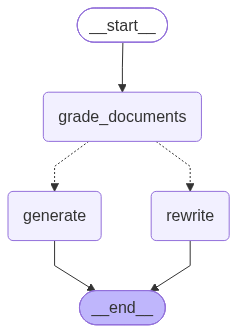

In [13]:
# Render the compiled LangGraph directly inside the notebook.
#
# This uses Mermaid's graphical representation of the graph.

from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [14]:
# We are extending our graph state.
#
# Previously we stored:
# - question
# - documents
# - relevant
#
# Now we also need to store the answer generated
# by the LLM.

from typing import TypedDict
from langchain_core.documents import Document


class GraphState(TypedDict):

    # User's original question.
    question: str

    # Documents retrieved from ChromaDB.
    documents: list[Document]

    # Result of the retrieval relevance grader.
    relevant: bool

    # Final answer generated by the LLM.
    answer: str


print("Updated GraphState created successfully.")

Updated GraphState created successfully.


In [15]:
# This node generates an answer using the retrieved documents.
#
# IMPORTANT:
# This node is only reached when the retrieval grader
# determines that the documents are relevant.

def generate_answer(state: GraphState) -> GraphState:

    # Get the question from the graph state.
    question = state["question"]

    # Get the documents retrieved from ChromaDB.
    documents = state["documents"]

    # Combine the retrieved documents into one context.
    context = "\n\n".join(
        document.page_content
        for document in documents
    )

    # Create the RAG generation prompt.
    prompt = f"""
    You are a helpful AI assistant.

    Answer the user's question using ONLY the information
    provided in the context below.

    If the answer cannot be found in the context,
    say that the information is not available
    in the provided documents.

    Context:
    --------------------
    {context}
    --------------------

    Question:
    {question}

    Answer:
    """

    # Generate the answer using our Groq LLM.
    response = llm.invoke(prompt)

    # Store the generated answer in the graph state.
    return {
        "question": question,
        "documents": documents,
        "relevant": state["relevant"],
        "answer": response.content
    }


print("Real generation node created successfully.")

Real generation node created successfully.


In [16]:
# We test the generation node independently first.
#
# This helps us verify that:
# Retrieval → Context → LLM → Answer
#
# is working correctly before we connect everything
# into the LangGraph workflow.

test_state = {
    "question": "How does the Transformer architecture use attention?",
    "documents": retriever.invoke(
        "How does the Transformer architecture use attention?"
    ),
    "relevant": True,
    "answer": ""
}


# Run the generation node.
result = generate_answer(test_state)


print("QUESTION:")
print(result["question"])

print("\nGENERATED ANSWER:")
print(result["answer"])

QUESTION:
How does the Transformer architecture use attention?

GENERATED ANSWER:
Based on the provided context, the Transformer architecture uses multi-head attention in three different ways:

1.  **Encoder-Decoder Attention:** In these layers, queries come from the previous decoder layer, while memory keys and values come from the output of the encoder. This allows every position in the decoder to attend to all positions in the input sequence.
2.  **Encoder Self-Attention:** The encoder contains self-attention layers where keys, values, and queries all come from the same place (the output of the previous layer in the encoder). This allows each position in the encoder to attend to all positions in the previous layer of the encoder.
3.  **Decoder Self-Attention:** The decoder uses self-attention layers that allow each position in the decoder to attend to all positions in the decoder up to and including that position.

Additionally, the context notes that the encoder is composed of a st

In [17]:
# ============================================================
# GENERATION STAGE
# ============================================================
#
# In this stage, we connect the retrieval-grading process
# with the actual answer generation step.
#
# If the Retrieval Grader finds the retrieved documents
# relevant, we pass the question and retrieved context
# to the LLM to generate a grounded answer.
#
# We also add the generated answer to our LangGraph state
# so that later nodes (such as the Grounding/Hallucination
# Grader) can evaluate the answer.
#
# Workflow:
#
# Question → Retrieve → Grade → Relevant → Generate Answer
#
# The generation node is first tested independently before
# being connected to the complete LangGraph workflow.
# This makes debugging and validation easier.
# ============================================================

In [18]:
# QUERY REWRITING STAGE

# When the Retrieval Grader determines that our documents
# are not relevant, we should not immediately generate
# an answer.
#
# Instead, we will rewrite the user's question into a
# clearer and more retrieval-friendly query.
#
# We therefore add "rewritten_query" to our graph state.

class GraphState(TypedDict):

    # Original user question.
    question: str

    # Documents retrieved from our knowledge base.
    documents: list[Document]

    # Retrieval relevance decision.
    relevant: bool

    # Generated answer.
    answer: str

    # Improved query produced by the query rewriter.
    rewritten_query: str


print("GraphState updated with rewritten_query.")

GraphState updated with rewritten_query.


In [19]:
# The Query Rewriter improves the original user question
# when the initial retrieval fails.
#
# The goal is NOT to answer the question.
# The goal is to produce a better query for another
# retrieval/search operation.

def rewrite_query(state: GraphState) -> GraphState:

    # Get the original user question.
    question = state["question"]

    # Ask the LLM to reformulate the question.
    rewrite_prompt = f"""
    You are a query rewriting assistant.

    Rewrite the user's question so that it becomes
    clearer, more specific, and more useful for
    information retrieval.

    Do NOT answer the question.

    Return only the rewritten search query.

    Original question:
    {question}
    """

    # Use our Groq LLM to rewrite the query.
    response = llm.invoke(rewrite_prompt)

    # Remove unnecessary whitespace.
    rewritten_query = response.content.strip()

    # Return the updated graph state.
    return {
        "question": question,
        "documents": state["documents"],
        "relevant": state["relevant"],
        "answer": state["answer"],
        "rewritten_query": rewritten_query
    }


print("Query rewriting node created successfully.")

Query rewriting node created successfully.


In [20]:
# Test the query rewriter independently before connecting
# it to our LangGraph.
#
# We intentionally use a short/vague question to see
# whether the LLM can make it more retrieval-friendly.

test_state = {
    "question": "attention BERT how?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": ""
}


# Run the query rewriting node.
result = rewrite_query(test_state)


print("ORIGINAL QUERY:")
print(result["question"])

print("\nREWRITTEN QUERY:")
print(result["rewritten_query"])

ORIGINAL QUERY:
attention BERT how?

REWRITTEN QUERY:
How does the BERT model utilize the self-attention mechanism?


In [21]:
# BUILDING THE REAL LANGGRAPH WORKFLOW

# We now connect the actual nodes we created:
#
# 1. grade_documents
# 2. generate_answer
# 3. rewrite_query
#
# The graph will make a decision after grading:
#
# Relevant documents
#       ↓
#   Generate Answer
#
# Irrelevant documents
#       ↓
#   Rewrite Query
#
# ============================================================

from langgraph.graph import StateGraph, START, END

workflow = StateGraph(GraphState)

# Add our real nodes
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate_answer)
workflow.add_node("rewrite", rewrite_query)

# START → Retrieval + Grading
workflow.add_edge(START, "grade_documents")

# After grading, choose the next node
workflow.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {
        "generate": "generate",
        "rewrite": "rewrite"
    }
)

# Both branches currently end here
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", END)

# Compile the graph
app = workflow.compile()

print("VeriRAG graph compiled successfully.")

VeriRAG graph compiled successfully.


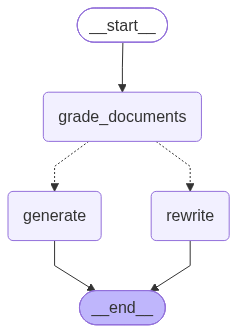

In [22]:
# VISUALIZE THE CURRENT AGENTIC RAG GRAPH

# This helps us verify that LangGraph has created
# the conditional workflow we intended.
#
# ============================================================

from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [23]:
# ============================================================
# TEST THE COMPLETE LANGGRAPH WORKFLOW
# ============================================================
#
# We use a question that should be answered from our
# internal PDF knowledge base.
#
# Expected route:
#
# Question
#    ↓
# Grade Documents
#    ↓
# Relevant = True
#    ↓
# Generate Answer
#    ↓
# END
#
# ============================================================

test_state = {
    "question": "How does the Transformer architecture use attention?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": ""
}

result = app.invoke(test_state)

print("QUESTION:")
print(result["question"])

print("\nRELEVANT:")
print(result["relevant"])

print("\nANSWER:")
print(result["answer"])

print("\nREWRITTEN QUERY:")
print(result["rewritten_query"])

QUESTION:
How does the Transformer architecture use attention?

RELEVANT:
True

ANSWER:
Based on the provided context, the Transformer architecture uses multi-head attention in three different ways:

1.  **Encoder-Decoder Attention:** In these layers, queries come from the previous decoder layer, while memory keys and values come from the output of the encoder. This allows every position in the decoder to attend to all positions in the input sequence.
2.  **Encoder Self-Attention:** The encoder contains self-attention layers where keys, values, and queries all come from the same place (the output of the previous layer in the encoder). This allows each position in the encoder to attend to all positions in the previous layer of the encoder.
3.  **Decoder Self-Attention:** The decoder uses self-attention layers that allow each position in the decoder to attend to all positions in the decoder up to and including that position.

Additionally, the context notes that the encoder is composed o

## Setting up the web fallback(tavily) after the irrelevancy (Step where our VeriRAG becomes truly agentic)

In [24]:

# TAVILY WEB SEARCH SETUP

# Tavily will be our external knowledge fallback.

# If the internal PDF documents are not relevant,we will use the rewritten query to search the web.

# The Tavily API key should already be stored in .env:

# TAVILY_API_KEY=your_key

import os
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

tavily_search = TavilySearchResults(
    max_results=3
)

print("Tavily web search configured successfully.")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20340\2658603191.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


Tavily web search configured successfully.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20340\2658603191.py:17: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(


In [25]:
# WEB FALLBACK NODE

# This node is executed when the internal documents are judged to be irrelevant.

# Flow:

# rewritten_query
#       ↓
#    Tavily Search
#       ↓
# Web search results
#       ↓
# Store them in GraphState

def web_search(state: GraphState) -> GraphState:
    # Use the improved query generated by the query rewriter
    rewritten_query = state["rewritten_query"]

    # Search the web using Tavily
    search_results = tavily_search.invoke(rewritten_query)

    # Convert Tavily results into a simple text context
    web_documents = []

    for result in search_results:
        web_documents.append(
            Document(
                page_content=result.get("content", ""),
                metadata={
                    "source": "web",
                    "title": result.get("title", ""),
                    "url": result.get("url", "")
                }
            )
        )

    return {
        "question": state["question"],
        "documents": web_documents,
        "relevant": False,
        "answer": state["answer"],
        "rewritten_query": rewritten_query
    }

print("Web fallback node created successfully.")

Web fallback node created successfully.


In [26]:
# WHY CONVERT TAVILY RESULTS INTO LANGCHAIN DOCUMENTS?

# Our internal PDF retrieval already returns information
# in LangChain's Document format:
#
# Document
# ├── page_content
# └── metadata
#     ├── source_file
#     └── page
#
# Tavily returns web search results in a different format:
#
# Web Result
# ├── content
# ├── title
# └── url
#
# We convert each Tavily result into a LangChain Document
# so that both internal and external knowledge sources
# follow the SAME structure.
#
# This gives our pipeline a unified representation:
#
#        Internal PDF
#             ↓
#          Document
#             ↑
#        same format
#             ↑
#          Document
#             ↑
#          Tavily Web
#
# Because both sources use the same Document structure,
# the generation node and later Grounding/Hallucination
# Grader can process them without needing separate logic.
# This makes the architecture cleaner, reusable, and easier
# to extend with additional knowledge sources in the future.

In [27]:
# TESTING TAVILY WEB FALLBACK

# We deliberately use a question that is unlikely to be answered by our local research papers.

# This lets us verify that Tavily can provide external
# knowledge when internal retrieval fails.

test_state = {
    "question": "What are the latest applications of AI agents?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": "latest applications of AI agents"
}

result = web_search(test_state)

print("WEB RESULTS:", len(result["documents"]))

for i, document in enumerate(result["documents"]):

    print(f"\n{'=' * 70}")
    print(f"WEB RESULT {i + 1}")
    print(f"{'=' * 70}")

    print("TITLE:")
    print(document.metadata["title"])

    print("\nURL:")
    print(document.metadata["url"])

    print("\nCONTENT:")
    print(document.page_content[:500])

WEB RESULTS: 3

WEB RESULT 1
TITLE:
AI Agents in action: 20+ real-world business applications across industries

URL:
https://toloka.ai/blog/ai-agents-in-action-20-real-world-business-applications-across-industries

CONTENT:
Siemens Industrial Copilot, developed with Microsoft and launched in 2023, is evolving into a multi-agent system for industrial automation. The latest AI agents—unveiled at Automate 2025—go beyond query-based support, autonomously managing tasks across the production lifecycle. Source: Siemens

### AI Agent market: from niche to necessary

The global AI agent market is growing fast. Grand View Research estimates its size at $5.40 billion in 2024 and $7.60 billion in 2025, growing at a CAGR of 45

WEB RESULT 2
TITLE:
Top AI agent use cases across industries | Redpanda

URL:
https://www.redpanda.com/blog/ai-agent-use-cases-across-industries

CONTENT:
### AI agents in autonomous vehicles

Autonomous vehicles are one of the most impressive applications of AI agents. Se

In [28]:
# CONNECT THE WEB FALLBACK TO LANGGRAPH

# Previously, the REWRITE branch stopped after rewriting
# the user's query.
#
# We now add the web_search node:
#
# Irrelevant Documents
#        ↓
#   Rewrite Query
#        ↓
#    Web Search
#        ↓
#     Generate
#        ↓
#       END
#
# This creates the external knowledge fallback mechanism.
# ============================================================

workflow = StateGraph(GraphState)

# Add all real nodes
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate_answer)
workflow.add_node("rewrite", rewrite_query)
workflow.add_node("web_search", web_search)

# Starting point
workflow.add_edge(START, "grade_documents")

# Decide whether internal documents are useful
workflow.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {
        "generate": "generate",
        "rewrite": "rewrite"
    }
)

# If documents are irrelevant:
# Rewrite the query first, then search the web.
workflow.add_edge("rewrite", "web_search")

# Web results are now stored in state["documents"],
# so the same generation node can use them.
workflow.add_edge("web_search", "generate")

# Generation is the final step
workflow.add_edge("generate", END)

# Compile the updated graph
app = workflow.compile()

print("VeriRAG graph with web fallback compiled successfully.")

VeriRAG graph with web fallback compiled successfully.


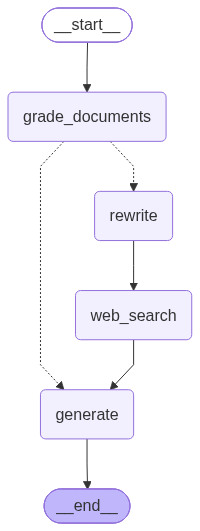

In [29]:
# VISUALIZE THE COMPLETE FALLBACK FLOW

# We should now have TWO possible paths:
#
# PATH 1:
# Internal documents are relevant
#       ↓
#    Generate
#
# PATH 2:
# Internal documents are irrelevant
#       ↓
#    Rewrite Query
#       ↓
#    Tavily Web Search
#       ↓
#    Generate
#
# ============================================================

from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [31]:
# TESTING THE COMPLETE AGENTIC FALLBACK

# This question should ideally fail the internal retrieval
# relevance check.
#
# Expected flow:
#
# Question
#   ↓
# Internal Retrieval
#   ↓
# Retrieval Grader → False
#   ↓
# Query Rewriting
#   ↓
# Tavily Web Search
#   ↓
# Generate Answer
#
# ============================================================

test_state = {
    "question": "When mahatma gandhi was born ?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": ""
}

result = app.invoke(test_state)

print("QUESTION:")
print(result["question"])

print("\nRELEVANT:")
print(result["relevant"])

print("\nREWRITTEN QUERY:")
print(result["rewritten_query"])

print("\nNUMBER OF FINAL DOCUMENTS:")
print(len(result["documents"]))

print("\nGENERATED ANSWER:")
print(result["answer"])

QUESTION:
When mahatma gandhi was born ?

RELEVANT:
False

REWRITTEN QUERY:
Mahatma Gandhi birth date

NUMBER OF FINAL DOCUMENTS:
3

GENERATED ANSWER:
Mahatma Gandhi was born on October 2, 1869.


In [32]:
# GROUNDING GRADER — STATE UPDATE

# Our Retrieval Grader checked the INPUT:
#
#     Are the retrieved documents relevant?
#
# Now we need another evaluator for the OUTPUT:
#
#     Is the generated answer actually supported
#     by the retrieved documents?
#
# Therefore, our state needs to store whether the final
# answer is grounded in the provided context.
#
# ============================================================

from typing import TypedDict
from langchain_core.documents import Document


class GraphState(TypedDict):
    question: str
    documents: list[Document]
    relevant: bool
    answer: str
    rewritten_query: str
    grounded: bool


print("GraphState updated with grounding information.")

GraphState updated with grounding information.


In [33]:
# STRUCTURED GROUNDING GRADER
# We use the LLM as a second evaluator.
#
# Retrieval Grader:
#     "Are the documents relevant?"
#
# Grounding Grader:
#     "Is the generated answer supported by those documents?"
#
# We again use structured output so that the result is a reliable boolean decision rather than free-form text.


from pydantic import BaseModel, Field


class GroundingGrade(BaseModel):

    grounded: bool = Field(
        description=(
            "True if the generated answer is fully supported "
            "by the provided source documents; otherwise False."
        )
    )


# Use our working Qwen model with structured output.
grounding_grader_llm = llm.with_structured_output(
    GroundingGrade
)


print("Structured grounding grader created successfully.")

Structured grounding grader created successfully.


In [34]:
# TEST THE GROUNDING GRADER

# We create:
#
# 1. A source document containing a known fact.
# 2. An answer that agrees with the source.
#
# Expected:
#
#     grounded = True

test_document = Document(
    page_content=(
        "Mahatma Gandhi was born on October 2, 1869, "
        "in Porbandar, India."
    ),
    metadata={
        "source": "test"
    }
)

test_answer = (
    "Mahatma Gandhi was born on October 2, 1869, "
    "in Porbandar, India."
)


grounding_prompt = f"""
You are a grounding grader.

Determine whether the answer is fully supported
by the provided source documents.

Source Documents:
--------------------
{test_document.page_content}
--------------------

Answer:
--------------------
{test_answer}
--------------------

Return grounded=True if the answer is supported
by the source documents.

Return grounded=False if the answer contains claims
that are not supported by the source documents.
"""


grade = grounding_grader_llm.invoke(
    grounding_prompt
)


print("ANSWER:")
print(test_answer)

print("\nGROUNDING GRADE:")
print(grade.grounded)

ANSWER:
Mahatma Gandhi was born on October 2, 1869, in Porbandar, India.

GROUNDING GRADE:
True


In [35]:
# ============================================================
# TEST THE GROUNDING GRADER — UNSUPPORTED ANSWER
# ============================================================
#
# Our source says:
#
#     Gandhi was born on October 2, 1869,
#     in Porbandar, India.
#
# But the answer deliberately contains a different
# birth date.
#
# Therefore, the answer is NOT supported by the source.
#
# Expected:
#
#     grounded = False
# ============================================================

test_answer = (
    "Mahatma Gandhi was born on October 5, 1869, "
    "in Porbandar, India."
)

grounding_prompt = f"""
You are a strict grounding grader.

Determine whether the answer is fully supported
by the provided source document.

Source Document:
--------------------
{test_document.page_content}
--------------------

Answer:
--------------------
{test_answer}
--------------------

Rules:

1. Check the factual claims in the answer against the source.
2. If the answer contradicts the source, return False.
3. If the answer contains information not supported by
   the source, return False.
4. Return True only if the answer is fully supported
   by the source.
5. Do not use outside knowledge.

Return the result using the GroundingGrade schema.
"""

grade = grounding_grader_llm.invoke(
    grounding_prompt
)

print("SOURCE:")
print(test_document.page_content)

print("\nANSWER:")
print(test_answer)

print("\nGROUNDING GRADE:")
print(grade.grounded)

SOURCE:
Mahatma Gandhi was born on October 2, 1869, in Porbandar, India.

ANSWER:
Mahatma Gandhi was born on October 5, 1869, in Porbandar, India.

GROUNDING GRADE:
False


In [36]:
# GROUNDING GRADER NODE

# We have already tested the grounding grader independently.
#
# Now we turn it into a LangGraph node.
#
# Input:
#     state["documents"]
#     state["answer"]
#
# Output:
#     state["grounded"]
#
# The node checks whether the generated answer is supported by the documents that were used to generate it.

def grade_grounding(state: GraphState) -> GraphState:

    question = state["question"]
    documents = state["documents"]
    answer = state["answer"]

    # Combine all source documents into one context.
    documents_text = "\n\n".join(
        document.page_content
        for document in documents
    )

    grounding_prompt = f"""
You are a strict grounding grader.

Determine whether the generated answer is fully
supported by the provided source documents.

Question:
{question}

Source Documents:
--------------------
{documents_text}
--------------------

Generated Answer:
--------------------
{answer}
--------------------

Rules:

1. Check the factual claims in the answer against
   the source documents.
2. If a claim contradicts the sources, return False.
3. If a claim is not supported by the sources, return False.
4. Return True only if the answer is fully supported
   by the provided sources.
5. Do not use outside knowledge.

Return the result using the GroundingGrade schema.
"""

    # Ask the structured LLM grader for its decision.
    grade = grounding_grader_llm.invoke(
        grounding_prompt
    )

    # Store the grounding decision in the graph state.
    return {
        "question": question,
        "documents": documents,
        "relevant": state["relevant"],
        "answer": answer,
        "rewritten_query": state["rewritten_query"],
        "grounded": grade.grounded
    }


print("Grounding grader node created successfully.")

Grounding grader node created successfully.


In [ ]:
# GROUNDING CONDITIONAL ROUTER


# After generating an answer, the Grounding Grader checks
# whether the answer is supported by the retrieved sources.
#
# If grounded:
#
#     → END
#
# If NOT grounded:
#
#     → SELF-CORRECTION
#
# The self-correction node will be added next.
# ============================================================

def route_after_grounding(state: GraphState) -> str:

    if state["grounded"]:
        return "end"

    else:
        return "self_correct"


print("Grounding conditional router created successfully.")

Grounding conditional router created successfully.


In [38]:
# ============================================================
# TEST THE GROUNDING NODE
# ============================================================
#
# We create a state containing:
#
#     Source document
#     Generated answer
#
# The answer exactly matches the source.
#
# Expected:
#
#     grounded = True
# ============================================================

test_state = {
    "question": "When was Mahatma Gandhi born?",

    "documents": [
        Document(
            page_content=(
                "Mahatma Gandhi was born on October 2, 1869, "
                "in Porbandar, India."
            ),
            metadata={"source": "test"}
        )
    ],

    "relevant": True,

    "answer": (
        "Mahatma Gandhi was born on October 2, 1869, "
        "in Porbandar, India."
    ),

    "rewritten_query": "",

    "grounded": False
}

result = grade_grounding(test_state)

print("QUESTION:")
print(result["question"])

print("\nANSWER:")
print(result["answer"])

print("\nGROUNDED:")
print(result["grounded"])

QUESTION:
When was Mahatma Gandhi born?

ANSWER:
Mahatma Gandhi was born on October 2, 1869, in Porbandar, India.

GROUNDED:
True


In [39]:
# SELF-CORRECTION — STATE UPDATE
# If the Grounding Grader detects that an answer contains unsupported information, we need to regenerate the answer.
# We therefore add a counter to our state.
#
# This counter is important because we do NOT want an
# infinite self-correction loop.
#
# Example:
#
#     Generate
#        ↓
#     Grounding → False
#        ↓
#     Self-Correct
#        ↓
#     Generate
#        ↓
#     Grounding → False
#        ↓
#     Stop after maximum attempts


class GraphState(TypedDict):
    question: str
    documents: list[Document]
    relevant: bool
    answer: str
    rewritten_query: str
    grounded: bool
    correction_attempts: int


print("GraphState updated with correction tracking.")

GraphState updated with correction tracking.


In [40]:
# SELF-CORRECTION NODE
# This node is executed when the Grounding Grader says:
#
#     grounded = False
#
# The LLM receives:
#
#     1. Original question
#     2. Retrieved source documents
#     3. Previous answer
#
# It must produce a new answer using ONLY the sources.
#
# ============================================================

def self_correct(state: GraphState) -> GraphState:

    question = state["question"]
    documents = state["documents"]
    previous_answer = state["answer"]

    # Combine the available source documents.
    context = "\n\n".join(
        document.page_content
        for document in documents
    )

    correction_prompt = f"""
You are correcting an answer generated by an AI assistant.

The previous answer may contain information that is not
supported by the provided source documents.

Your task is to generate a new answer using ONLY the
information contained in the source documents.

Do NOT use outside knowledge.

Question:
{question}

Source Documents:
--------------------
{context}
--------------------

Previous Answer:
--------------------
{previous_answer}
--------------------

Generate a corrected answer that is fully supported
by the source documents.

If the source documents do not contain enough information
to answer the question, explicitly say that the information
is not available in the provided sources.
"""

    response = llm.invoke(correction_prompt)

    return {
        "question": question,
        "documents": documents,
        "relevant": state["relevant"],
        "answer": response.content,
        "rewritten_query": state["rewritten_query"],
        "grounded": False,
        "correction_attempts": state["correction_attempts"] + 1
    }


print("Self-correction node created successfully.")

Self-correction node created successfully.


In [41]:
# TEST SELF-CORRECTION

# Source:
#     Gandhi was born on October 2, 1869.
#
# Previous answer:
#     Gandhi was born on October 5, 1869.
#
# Expected:
#     The corrected answer should use October 2, 1869.
# ============================================================

test_state = {
    "question": "When was Mahatma Gandhi born?",

    "documents": [
        Document(
            page_content=(
                "Mahatma Gandhi was born on October 2, 1869, "
                "in Porbandar, India."
            ),
            metadata={"source": "test"}
        )
    ],

    "relevant": True,

    "answer": (
        "Mahatma Gandhi was born on October 5, 1869, "
        "in Porbandar, India."
    ),

    "rewritten_query": "",

    "grounded": False,

    "correction_attempts": 0
}

result = self_correct(test_state)

print("PREVIOUS ANSWER:")
print(test_state["answer"])

print("\nCORRECTED ANSWER:")
print(result["answer"])

print("\nCORRECTION ATTEMPTS:")
print(result["correction_attempts"])

PREVIOUS ANSWER:
Mahatma Gandhi was born on October 5, 1869, in Porbandar, India.

CORRECTED ANSWER:
Mahatma Gandhi was born on October 2, 1869, in Porbandar, India.

CORRECTION ATTEMPTS:
1


In [42]:
# SELF-CORRECTION ROUTER

# The Grounding Grader has two possible outcomes:
#
#     grounded = True
#          ↓
#         END
#
#     grounded = False
#          ↓
#     Self-Correction
#
# However, we also need a safety limit.
# Otherwise, a model that repeatedly produces unsupported
# answers could create an infinite loop.


MAX_CORRECTION_ATTEMPTS = 2


def route_after_grounding(state: GraphState) -> str:

    # If the answer is properly supported, finish.
    if state["grounded"]:
        return "end"

    # If the answer is not grounded but we still have
    # correction attempts available, try correcting it.
    if state["correction_attempts"] < MAX_CORRECTION_ATTEMPTS:
        return "self_correct"

    # If we've reached the maximum number of attempts,
    # stop instead of looping forever.
    return "end"


print("Self-correction routing function created successfully.")

Self-correction routing function created successfully.


In [43]:
# BUILD THE COMPLETE VERIRAG GRAPH
# Complete architecture:
#
#                         START
#                           ↓
#                    Grade Documents
#                           ↓
#                      Relevant?
#                     /         \
#                   YES          NO
#                    ↓            ↓
#                 Generate     Rewrite
#                                 ↓
#                              Web Search
#                                 ↓
#                              Generate
#                    └──────┬─────┘
#                           ↓
#                    Grounding Grader
#                           ↓
#                       Grounded?
#                      /          \
#                    YES           NO
#                     ↓             ↓
#                    END       Self-Correct
#                                   ↓
#                            Grounding Grader
#
# ============================================================

from langgraph.graph import StateGraph, START, END


workflow = StateGraph(GraphState)

# ------------------------------------------------------------
# Add nodes
# ------------------------------------------------------------

workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate_answer)
workflow.add_node("rewrite", rewrite_query)
workflow.add_node("web_search", web_search)
workflow.add_node("grade_grounding", grade_grounding)
workflow.add_node("self_correct", self_correct)


# ------------------------------------------------------------
# Initial retrieval + grading
# ------------------------------------------------------------

workflow.add_edge(
    START,
    "grade_documents"
)


# ------------------------------------------------------------
# Decide whether internal documents are useful
# ------------------------------------------------------------

workflow.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {
        "generate": "generate",
        "rewrite": "rewrite"
    }
)


# ------------------------------------------------------------
# Web fallback
# ------------------------------------------------------------

workflow.add_edge(
    "rewrite",
    "web_search"
)

workflow.add_edge(
    "web_search",
    "generate"
)


# ------------------------------------------------------------
# After generation, check grounding
# ------------------------------------------------------------

workflow.add_edge(
    "generate",
    "grade_grounding"
)


# ------------------------------------------------------------
# Decide whether to finish or self-correct
# ------------------------------------------------------------

workflow.add_conditional_edges(
    "grade_grounding",
    route_after_grounding,
    {
        "end": END,
        "self_correct": "self_correct"
    }
)


# ------------------------------------------------------------
# Self-correction goes back to grounding evaluation.
# ------------------------------------------------------------

workflow.add_edge(
    "self_correct",
    "grade_grounding"
)


# Compile the complete graph.
app = workflow.compile()

print("Complete VeriRAG graph compiled successfully.")

Complete VeriRAG graph compiled successfully.


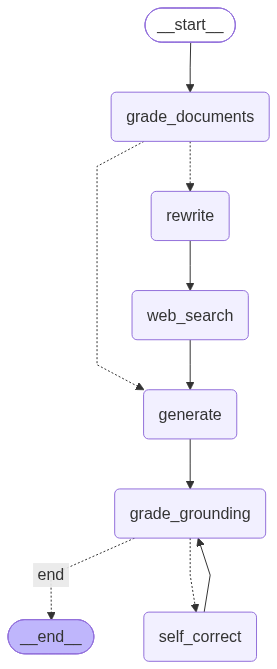

In [44]:
# VISUALIZE THE COMPLETE VERIRAG GRAPH
# This visualization lets us verify that all of our
# decision-making paths are connected correctly.

from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [45]:
# END-TO-END TEST 1 — INTERNAL KNOWLEDGE PATH

# We use a question that should be answerable from our
# research papers.
#
# Expected flow:
#
# Question
#    ↓
# Retrieval
#    ↓
# Retrieval Grader → TRUE
#    ↓
# Generate
#    ↓
# Grounding Grader → TRUE
#    ↓
# END

test_state = {
    "question": "How does the Transformer architecture use attention?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": "",
    "grounded": False,
    "correction_attempts": 0
}

events = list(
    app.stream(
        test_state,
        stream_mode="updates"
    )
)

print("EXECUTED NODES:")
for event in events:
    print("-", list(event.keys())[-1])

print("\nFINAL STATE:")
final_state = {}
for event in events:
    final_state.update(event[list(event.keys())[-1]])

print("\nQUESTION:")
print(final_state.get("question"))

print("\nRELEVANT:")
print(final_state.get("relevant"))

print("\nGROUNDED:")
print(final_state.get("grounded"))

print("\nCORRECTION ATTEMPTS:")
print(final_state.get("correction_attempts"))

print("\nANSWER:")
print(final_state.get("answer"))

EXECUTED NODES:
- grade_documents
- generate
- grade_grounding

FINAL STATE:

QUESTION:
How does the Transformer architecture use attention?

RELEVANT:
True

GROUNDED:
True

CORRECTION ATTEMPTS:
None

ANSWER:
Based on the provided context, the Transformer architecture uses multi-head attention in three different ways:

1.  **Encoder-Decoder Attention:** In these layers, queries come from the previous decoder layer, while memory keys and values come from the output of the encoder. This allows every position in the decoder to attend to all positions in the input sequence.
2.  **Encoder Self-Attention:** The encoder contains self-attention layers where keys, values, and queries all come from the same place (the output of the previous layer in the encoder). This allows each position in the encoder to attend to all positions in the previous layer of the encoder.
3.  **Decoder Self-Attention:** The decoder contains self-attention layers that allow each position in the decoder to attend to al

In [46]:
# END-TO-END TEST 2 — WEB FALLBACK PATH

# This question should not be answerable from our Transformer/BERT/LLM research papers.
#
# Expected flow:
#
# Question
#    ↓
# Retrieval
#    ↓
# Retrieval Grader → FALSE
#    ↓
# Rewrite Query
#    ↓
# Tavily Web Search
#    ↓
# Generate
#    ↓
# Grounding Grader
#    ↓
# END


test_state = {
    "question": "When was Mahatma Gandhi born?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": "",
    "grounded": False,
    "correction_attempts": 0
}

events = list(
    app.stream(
        test_state,
        stream_mode="updates"
    )
)

print("EXECUTED NODES:")
for event in events:
    print("-", list(event.keys())[-1])

print("\nFINAL STATE:")
final_state = {}
for event in events:
    final_state.update(event[list(event.keys())[-1]])

print("\nQUESTION:")
print(final_state.get("question"))

print("\nRELEVANT:")
print(final_state.get("relevant"))

print("\nREWRITTEN QUERY:")
print(final_state.get("rewritten_query"))

print("\nGROUNDED:")
print(final_state.get("grounded"))

print("\nCORRECTION ATTEMPTS:")
print(final_state.get("correction_attempts"))

print("\nANSWER:")
print(final_state.get("answer"))

EXECUTED NODES:
- grade_documents
- rewrite
- web_search
- generate
- grade_grounding

FINAL STATE:

QUESTION:
When was Mahatma Gandhi born?

RELEVANT:
False

REWRITTEN QUERY:
Mahatma Gandhi birth date

GROUNDED:
True

CORRECTION ATTEMPTS:
None

ANSWER:
Mahatma Gandhi was born on October 2, 1869.


In [ ]:
#Problem in the project
'''# END-TO-END TEST 3 — SELF-CORRECTION

# We intentionally provide an incorrect answer.
#
# Source:
#     October 2, 1869
#
# Wrong answer:
#     October 5, 1869
#
# The Grounding Grader should detect the problem.
# Then Self-Correction should regenerate the answer.

# Expected conceptual flow:
#
# Grounding → FALSE
#      ↓
# Self-Correct
#      ↓
# Grounding → TRUE


test_state = {
    "question": "When was Mahatma Gandhi born?",

    "documents": [
        Document(
            page_content=(
                "Mahatma Gandhi was born on October 2, 1869, "
                "in Porbandar, India."
            ),
            metadata={"source": "test"}
        )
    ],

    "relevant": True,

    # Deliberately incorrect answer
    "answer": (
        "Mahatma Gandhi was born on October 5, 1869, "
        "in Porbandar, India."
    ),

    "rewritten_query": "",
    "grounded": False,
    "correction_attempts": 0
}

# Test the grounding grader first.
state_after_grounding = grade_grounding(test_state)

print("INITIAL ANSWER:")
print(state_after_grounding["answer"])

print("\nINITIAL GROUNDING:")
print(state_after_grounding["grounded"])

# If the answer is not grounded, trigger self-correction.
if not state_after_grounding["grounded"]:

    corrected_state = self_correct(
        state_after_grounding
    )

    print("\nCORRECTED ANSWER:")
    print(corrected_state["answer"])

    print("\nCORRECTION ATTEMPTS:")
    print(corrected_state["correction_attempts"])

    # Check the corrected answer again.
    final_state = grade_grounding(
        corrected_state
    )

    print("\nFINAL GROUNDING:")
    print(final_state["grounded"])'''

INITIAL ANSWER:
Mahatma Gandhi was born on October 5, 1869, in Porbandar, India.

INITIAL GROUNDING:
False


KeyError: 'correction_attempts'

In [48]:
# FIX: PRESERVE CORRECTION ATTEMPTS
# The grounding node creates a new GraphState.
#
# Therefore, it must preserve ALL important state fields,
# including correction_attempts.
#
# Previously, correction_attempts was accidentally omitted.
#
# This caused:
#
#     KeyError: 'correction_attempts'
#
# when the self-correction node tried to access it.
# ============================================================

def grade_grounding(state: GraphState) -> GraphState:

    question = state["question"]
    documents = state["documents"]
    answer = state["answer"]

    # Combine all source documents into one context.
    documents_text = "\n\n".join(
        document.page_content
        for document in documents
    )

    grounding_prompt = f"""
You are a strict grounding grader.

Determine whether the generated answer is fully
supported by the provided source documents.

Question:
{question}

Source Documents:
--------------------
{documents_text}
--------------------

Generated Answer:
--------------------
{answer}
--------------------

Rules:

1. Check the factual claims in the answer against
   the source documents.
2. If a claim contradicts the sources, return False.
3. If a claim is not supported by the sources, return False.
4. Return True only if the answer is fully supported
   by the provided sources.
5. Do not use outside knowledge.

Return the result using the GroundingGrade schema.
"""

    grade = grounding_grader_llm.invoke(
        grounding_prompt
    )

    return {
        "question": question,
        "documents": documents,
        "relevant": state["relevant"],
        "answer": answer,
        "rewritten_query": state["rewritten_query"],
        "grounded": grade.grounded,

        # IMPORTANT:
        # Preserve the correction counter so that the
        # self-correction node can access it.
        "correction_attempts": state["correction_attempts"]
    }


print("Grounding grader node fixed successfully.")

Grounding grader node fixed successfully.


In [49]:
# REBUILD THE VERIRAG GRAPH
# We changed the grade_grounding node.
#
# Therefore, we recompile the LangGraph so that the graph
# uses the updated function.
#
# The architecture itself has NOT changed.
workflow = StateGraph(GraphState)

# Add all nodes
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate_answer)
workflow.add_node("rewrite", rewrite_query)
workflow.add_node("web_search", web_search)
workflow.add_node("grade_grounding", grade_grounding)
workflow.add_node("self_correct", self_correct)

# START → Retrieval + Grading
workflow.add_edge(
    START,
    "grade_documents"
)

# Retrieval grading → conditional routing
workflow.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {
        "generate": "generate",
        "rewrite": "rewrite"
    }
)

# Web fallback
workflow.add_edge("rewrite", "web_search")
workflow.add_edge("web_search", "generate")

# Generation → Grounding
workflow.add_edge(
    "generate",
    "grade_grounding"
)

# Grounding → END or Self-Correction
workflow.add_conditional_edges(
    "grade_grounding",
    route_after_grounding,
    {
        "end": END,
        "self_correct": "self_correct"
    }
)

# Self-correction → Grounding again
workflow.add_edge(
    "self_correct",
    "grade_grounding"
)

app = workflow.compile()

print("VeriRAG graph rebuilt successfully.")

VeriRAG graph rebuilt successfully.


In [ ]:
# Problem in the project solved
# TEST SELF-CORRECTION AGAIN#
# We deliberately start with an incorrect answer.
#
# Expected:
#
# Initial grounding:
#     False
#
# Self-correction:
#     correction_attempts = 1
#
# Final grounding:
#     True
# ============================================================

test_state = {
    "question": "When was Mahatma Gandhi born?",

    "documents": [
        Document(
            page_content=(
                "Mahatma Gandhi was born on October 2, 1869, "
                "in Porbandar, India."
            ),
            metadata={"source": "test"}
        )
    ],

    "relevant": True,

    "answer": (
        "Mahatma Gandhi was born on October 5, 1869, "
        "in Porbandar, India."
    ),

    "rewritten_query": "",
    "grounded": False,
    "correction_attempts": 0
}

# First grounding check
state_after_grounding = grade_grounding(test_state)

print("INITIAL ANSWER:")
print(state_after_grounding["answer"])

print("\nINITIAL GROUNDING:")
print(state_after_grounding["grounded"])

print("\nCORRECTION ATTEMPTS:")
print(state_after_grounding["correction_attempts"])


# If unsupported, perform self-correction
if not state_after_grounding["grounded"]:

    corrected_state = self_correct(
        state_after_grounding
    )

    print("\nCORRECTED ANSWER:")
    print(corrected_state["answer"])

    print("\nCORRECTION ATTEMPTS:")
    print(corrected_state["correction_attempts"])

    # Check the corrected answer again
    final_state = grade_grounding(
        corrected_state
    )

    print("\nFINAL GROUNDING:")
    print(final_state["grounded"])

INITIAL ANSWER:
Mahatma Gandhi was born on October 5, 1869, in Porbandar, India.

INITIAL GROUNDING:
False

CORRECTION ATTEMPTS:
0

CORRECTED ANSWER:
Mahatma Gandhi was born on October 2, 1869, in Porbandar, India.

CORRECTION ATTEMPTS:
1

FINAL GROUNDING:
True


In [51]:
# END-TO-END TEST — INTERNAL KNOWLEDGE PATH
# The question should be answerable from our research papers.
#
# Expected flow:
#
# START
#   ↓
# Retrieval + Retrieval Grader
#   ↓
# Relevant = TRUE
#   ↓
# Generate
#   ↓
# Grounding Grader
#   ↓
# Grounded = TRUE
#   ↓
# END
# ============================================================

test_state = {
    "question": "How does the Transformer architecture use attention?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": "",
    "grounded": False,
    "correction_attempts": 0
}

result = app.invoke(test_state)

print("QUESTION:")
print(result["question"])

print("\nRELEVANT:")
print(result["relevant"])

print("\nGROUNDED:")
print(result["grounded"])

print("\nCORRECTION ATTEMPTS:")
print(result["correction_attempts"])

print("\nNUMBER OF DOCUMENTS:")
print(len(result["documents"]))

print("\nANSWER:")
print(result["answer"])

QUESTION:
How does the Transformer architecture use attention?

RELEVANT:
True

GROUNDED:
True

CORRECTION ATTEMPTS:
0

NUMBER OF DOCUMENTS:
3

ANSWER:
Based on the provided context, the Transformer architecture uses multi-head attention in three different ways:

1.  **Encoder-Decoder Attention:** In these layers, queries come from the previous decoder layer, while memory keys and values come from the output of the encoder. This allows every position in the decoder to attend to all positions in the input sequence.
2.  **Encoder Self-Attention:** The encoder contains self-attention layers where keys, values, and queries all come from the same place (the output of the previous layer in the encoder). This allows each position in the encoder to attend to all positions in the previous layer of the encoder.
3.  **Decoder Self-Attention:** The decoder contains self-attention layers that allow each position in the decoder to attend to all positions in the decoder up to and including that posit

In [52]:
# END-TO-END TEST — WEB FALLBACK PATH
# This question is unrelated to our research papers.
#
# Expected flow:
#
# Retrieval
#    ↓
# Relevant = FALSE
#    ↓
# Rewrite Query
#    ↓
# Tavily Search
#    ↓
# Generate
#    ↓
# Grounding
#    ↓
# END
# ============================================================

test_state = {
    "question": "When was Mahatma Gandhi born?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": "",
    "grounded": False,
    "correction_attempts": 0
}

result = app.invoke(test_state)

print("QUESTION:")
print(result["question"])

print("\nRELEVANT:")
print(result["relevant"])

print("\nREWRITTEN QUERY:")
print(result["rewritten_query"])

print("\nGROUNDED:")
print(result["grounded"])

print("\nCORRECTION ATTEMPTS:")
print(result["correction_attempts"])

print("\nNUMBER OF FINAL DOCUMENTS:")
print(len(result["documents"]))

print("\nANSWER:")
print(result["answer"])

QUESTION:
When was Mahatma Gandhi born?

RELEVANT:
False

REWRITTEN QUERY:
Mahatma Gandhi birth date

GROUNDED:
True

CORRECTION ATTEMPTS:
0

NUMBER OF FINAL DOCUMENTS:
3

ANSWER:
Mahatma Gandhi was born on October 2, 1869.


In [ ]:
# INSPECTING FINAL SOURCES THAT TAVILY HAS SEARCHED FOR INFORMATION
# Every Document in our state represents a source used
# by the system.
#
# Internal PDF documents contain:
#
#     source_file
#     page
#
# Tavily documents contain:
#
#     title
#     url
#
# This unified Document structure will allow us to build proper source citations in the final application.


print("FINAL ANSWER:")
print(result["answer"])

print("\n" + "=" * 70)
print("SOURCES USED")
print("=" * 70)

for i, document in enumerate(result["documents"], start=1):

    print(f"\nSOURCE {i}")

    # Internal PDF source
    if document.metadata.get("source_file"):

        print(
            "Type: Internal PDF"
        )

        print(
            "File:",
            document.metadata.get("source_file")
        )

        print(
            "Page:",
            document.metadata.get("page")
        )

    # Tavily web source
    elif document.metadata.get("url"):

        print(
            "Type: Web"
        )

        print(
            "Title:",
            document.metadata.get("title")
        )

        print(
            "URL:",
            document.metadata.get("url")
        )

    else:

        print("Type: Unknown")

FINAL ANSWER:
Mahatma Gandhi was born on October 2, 1869.

SOURCES USED

SOURCE 1
Type: Web
Title: Mahatma Gandhi | Biography, Education, Religion ... - Britannica
URL: https://www.britannica.com/biography/Mahatma-Gandhi

SOURCE 2
Type: Web
Title: Mahatma Gandhi - Ministry of Culture
URL: https://culture.gov.in/mahatma-gandhi

SOURCE 3
Type: Web
Title: 🌷🇮🇳Mohandas Karamchand Gandhi (Mahatma ...
URL: https://www.facebook.com/groups/panindiapostal/posts/4436592096570155


In [ ]:
# FIX: PRESERVE COMPLETE GRAPH STATE

# Every LangGraph node receives the current state.

# A node should update only the fields it is responsible for
# while preserving the other fields needed by downstream nodes.
#
# This prevents fields such as:
#     answer
#     rewritten_query
#     grounded
#     correction_attempts
#
# from accidentally disappearing.

def grade_documents(state: GraphState) -> GraphState:

    question = state["question"]

    documents = retriever.invoke(question)

    documents_text = "\n\n".join(
        document.page_content
        for document in documents
    )

    grading_prompt = f"""
You are a retrieval relevance grader.

Determine whether the retrieved documents contain
information relevant to answering the question.

Question:
{question}

Retrieved Documents:
--------------------
{documents_text}
--------------------

Return True if the documents are relevant.
Return False if they are not relevant.
"""

    grade = grader_llm.invoke(grading_prompt)

    # Preserve the existing state and update only
    # the fields changed by this node.
    new_state = state.copy()

    new_state["documents"] = documents
    new_state["relevant"] = grade.relevant

    return new_state

In [55]:
# FIX: STATE PRESERVATION IN GENERATE / REWRITE / WEB SEARCH


def generate_answer(state: GraphState) -> GraphState:

    documents = state["documents"]

    context = "\n\n".join(
        document.page_content
        for document in documents
    )

    prompt = f"""
You are a helpful AI assistant.

Answer the user's question using ONLY the information
provided in the context below.

If the answer cannot be found in the context,
say that the information is not available
in the provided documents.

Context:
--------------------
{context}
--------------------

Question:
{state["question"]}

Answer:
"""

    response = llm.invoke(prompt)

    new_state = state.copy()
    new_state["answer"] = response.content

    return new_state


def rewrite_query(state: GraphState) -> GraphState:

    rewrite_prompt = f"""
You are a query rewriting assistant.

Rewrite the user's question so that it becomes
clearer, more specific, and more useful for
information retrieval.

Do NOT answer the question.

Return only the rewritten search query.

Original question:
{state["question"]}
"""

    response = llm.invoke(rewrite_prompt)

    new_state = state.copy()
    new_state["rewritten_query"] = response.content.strip()

    return new_state


def web_search(state: GraphState) -> GraphState:

    rewritten_query = state["rewritten_query"]

    search_results = tavily_search.invoke(rewritten_query)

    web_documents = []

    for result in search_results:

        web_documents.append(
            Document(
                page_content=result.get("content", ""),
                metadata={
                    "source": "web",
                    "title": result.get("title", ""),
                    "url": result.get("url", "")
                }
            )
        )

    new_state = state.copy()

    new_state["documents"] = web_documents

    return new_state

In [56]:
# REBUILD VERIRAG GRAPH

# We changed several node functions, so the previously compiled graph is outdated.

# Rebuild and compile it using the corrected nodes.


workflow = StateGraph(GraphState)

workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate_answer)
workflow.add_node("rewrite", rewrite_query)
workflow.add_node("web_search", web_search)
workflow.add_node("grade_grounding", grade_grounding)
workflow.add_node("self_correct", self_correct)

workflow.add_edge(START, "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {
        "generate": "generate",
        "rewrite": "rewrite"
    }
)

workflow.add_edge("rewrite", "web_search")
workflow.add_edge("web_search", "generate")

workflow.add_edge("generate", "grade_grounding")

workflow.add_conditional_edges(
    "grade_grounding",
    route_after_grounding,
    {
        "end": END,
        "self_correct": "self_correct"
    }
)

workflow.add_edge("self_correct", "grade_grounding")

app = workflow.compile()

print("VeriRAG graph rebuilt successfully.")

VeriRAG graph rebuilt successfully.


In [ ]:
# END-TO-END TEST — INTERNAL KNOWLEDGE


test_state = {
    "question": "How does the Transformer architecture use attention?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": "",
    "grounded": False,
    "correction_attempts": 0
}

result_internal = app.invoke(test_state)

print("QUESTION:")
print(result_internal["question"])

print("\nRELEVANT:")
print(result_internal["relevant"])

print("\nGROUNDED:")
print(result_internal["grounded"])

print("\nCORRECTION ATTEMPTS:")
print(result_internal["correction_attempts"])

print("\nANSWER:")
print(result_internal["answer"])

QUESTION:
How does the Transformer architecture use attention?

RELEVANT:
True

GROUNDED:
True

CORRECTION ATTEMPTS:
0

ANSWER:
Based on the provided context, the Transformer architecture uses multi-head attention in three different ways:

1.  **Encoder-Decoder Attention:** In these layers, queries come from the previous decoder layer, while memory keys and values come from the output of the encoder. This allows every position in the decoder to attend to all positions in the input sequence.
2.  **Encoder Self-Attention:** The encoder contains self-attention layers where keys, values, and queries all come from the same source (the output of the previous layer in the encoder). This allows each position in the encoder to attend to all positions in the previous encoder layer.
3.  **Decoder Self-Attention:** The decoder uses self-attention layers that allow each position in the decoder to attend to all positions in the decoder up to and including that position.

Additionally, the context no

In [ ]:
# END-TO-END TEST — WEB FALLBACK


test_state = {
    "question": "When was Mahatma Gandhi born?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": "",
    "grounded": False,
    "correction_attempts": 0
}

result_web = app.invoke(test_state)

print("QUESTION:")
print(result_web["question"])

print("\nRELEVANT:")
print(result_web["relevant"])

print("\nREWRITTEN QUERY:")
print(result_web["rewritten_query"])

print("\nGROUNDED:")
print(result_web["grounded"])

print("\nCORRECTION ATTEMPTS:")
print(result_web["correction_attempts"])

print("\nNUMBER OF DOCUMENTS:")
print(len(result_web["documents"]))

print("\nANSWER:")
print(result_web["answer"])

QUESTION:
When was Mahatma Gandhi born?

RELEVANT:
False

REWRITTEN QUERY:
Mahatma Gandhi birth date

GROUNDED:
True

CORRECTION ATTEMPTS:
0

NUMBER OF DOCUMENTS:
3

ANSWER:
Mahatma Gandhi was born on October 2, 1869.


In [ ]:
# STATE PRESERVATION CHECK
required_fields = [
    "question",
    "documents",
    "relevant",
    "answer",
    "rewritten_query",
    "grounded",
    "correction_attempts"
]

print("STATE VALIDATION")
print("=" * 50)

for field in required_fields:

    if field in result_web:
        print(f"✓ {field}")
    else:
        print(f"✗ {field}")

print("\nFINAL STATE KEYS:")
print(list(result_web.keys()))

STATE VALIDATION
✓ question
✓ documents
✓ relevant
✓ answer
✓ rewritten_query
✓ grounded
✓ correction_attempts

FINAL STATE KEYS:
['question', 'documents', 'relevant', 'answer', 'rewritten_query', 'grounded', 'correction_attempts']


In [60]:
# ============================================================
# SOURCE CITATION FORMATTER
# ============================================================
#
# Our documents can come from two sources:
#
# 1. Internal research PDFs
# 2. Tavily web search
#
# Both are represented as LangChain Documents.
#
# This function converts their metadata into a clean
# user-readable source list.
# ============================================================

def format_sources(documents: list[Document]) -> list[str]:

    sources = []

    for i, document in enumerate(documents, start=1):

        metadata = document.metadata

        # ----------------------------------------------------
        # Web source
        # ----------------------------------------------------
        if metadata.get("url"):

            title = metadata.get("title", "Web Source")
            url = metadata.get("url")

            sources.append(
                f"{i}. {title} — {url}"
            )

        # ----------------------------------------------------
        # Internal PDF source
        # ----------------------------------------------------
        elif metadata.get("source_file"):

            source_file = metadata.get(
                "source_file",
                "Unknown PDF"
            )

            page = metadata.get("page", "Unknown")

            sources.append(
                f"{i}. {source_file} — Page {page}"
            )

        # ----------------------------------------------------
        # Fallback
        # ----------------------------------------------------
        else:

            sources.append(
                f"{i}. Unknown source"
            )

    return sources

In [61]:
# ============================================================
# TEST SOURCE FORMATTER — WEB SEARCH
# ============================================================

sources = format_sources(
    result_web["documents"]
)

print("SOURCES")
print("=" * 70)

for source in sources:
    print(source)

SOURCES
1. Mahatma Gandhi | Biography, Education, Religion ... - Britannica — https://www.britannica.com/biography/Mahatma-Gandhi
2. Mahatma Gandhi - Ministry of Culture — https://culture.gov.in/mahatma-gandhi
3. 🌷🇮🇳Mohandas Karamchand Gandhi (Mahatma ... — https://www.facebook.com/groups/panindiapostal/posts/4436592096570155


In [62]:
# ============================================================
# TEST SOURCE FORMATTER — INTERNAL DOCUMENTS
# ============================================================

sources = format_sources(
    result_internal["documents"]
)

print("SOURCES")
print("=" * 70)

for source in sources:
    print(source)

SOURCES
1. Attention Is All You Need.pdf — Page 4
2. LLM.pdf — Page 4
3. Attention Is All You Need.pdf — Page 2


In [63]:
# ============================================================
# ADD SOURCES TO GRAPH STATE
# ============================================================
#
# Previously our final state contained:
#
# question
# documents
# relevant
# answer
# rewritten_query
# grounded
# correction_attempts
#
# Now we also want:
#
# sources
#
# This will contain clean user-readable source information.
# ============================================================

class GraphState(TypedDict):
    question: str
    documents: list[Document]
    relevant: bool
    answer: str
    rewritten_query: str
    grounded: bool
    correction_attempts: int
    sources: list[str]

print("GraphState updated with sources.")

GraphState updated with sources.


In [65]:
# ============================================================
# FINAL RESPONSE FORMATTER
# ============================================================
#
# This function prepares the information that our frontend
# will eventually display to the user.
#
# The LLM answer and source information remain separate.
# This is useful for Streamlit/FastAPI later.
# ============================================================

def build_final_response(state: GraphState) -> dict:

    sources = format_sources(
        state["documents"]
    )

    return {
        "answer": state["answer"],
        "sources": sources
    }


print("Final response formatter created.")

Final response formatter created.


In [66]:
# ============================================================
# TEST FINAL RESPONSE
# ============================================================

final_response = build_final_response(
    result_web
)

print("ANSWER")
print("=" * 70)
print(final_response["answer"])

print("\nSOURCES")
print("=" * 70)

for source in final_response["sources"]:
    print(source)

ANSWER
Mahatma Gandhi was born on October 2, 1869.

SOURCES
1. Mahatma Gandhi | Biography, Education, Religion ... - Britannica — https://www.britannica.com/biography/Mahatma-Gandhi
2. Mahatma Gandhi - Ministry of Culture — https://culture.gov.in/mahatma-gandhi
3. 🌷🇮🇳Mohandas Karamchand Gandhi (Mahatma ... — https://www.facebook.com/groups/panindiapostal/posts/4436592096570155


In [67]:
# ============================================================
# UPDATE GENERATION NODE
# ============================================================
#
# The generation node now also creates the source list.
#
# The actual answer is still generated ONLY from the
# retrieved documents.
#
# Sources are extracted from document metadata.
# ============================================================

def generate_answer(state: GraphState) -> GraphState:

    documents = state["documents"]

    context = "\n\n".join(
        document.page_content
        for document in documents
    )

    prompt = f"""
You are a helpful AI assistant.

Answer the user's question using ONLY the information
provided in the context below.

If the answer cannot be found in the context,
say that the information is not available
in the provided documents.

Context:
--------------------
{context}
--------------------

Question:
{state["question"]}

Answer:
"""

    response = llm.invoke(prompt)

    new_state = state.copy()

    new_state["answer"] = response.content

    # Create clean source information for the final response.
    new_state["sources"] = format_sources(documents)

    return new_state


print("Generation node updated successfully.")

Generation node updated successfully.


In [68]:
# ============================================================
# PRESERVE SOURCES THROUGH THE GRAPH
# ============================================================
#
# Since sources are now part of GraphState, every node that
# copies the state automatically preserves them.
#
# For nodes that replace the documents (especially web_search),
# we reset sources because the documents have changed.
# generate_answer() will recreate the correct source list.
# ============================================================

def web_search(state: GraphState) -> GraphState:

    rewritten_query = state["rewritten_query"]

    search_results = tavily_search.invoke(
        rewritten_query
    )

    web_documents = []

    for result in search_results:

        web_documents.append(
            Document(
                page_content=result.get("content", ""),
                metadata={
                    "source": "web",
                    "title": result.get("title", ""),
                    "url": result.get("url", "")
                }
            )
        )

    new_state = state.copy()

    # Replace irrelevant internal documents with web documents.
    new_state["documents"] = web_documents

    # These documents have not been passed to the generator yet.
    # Therefore sources will be populated by generate_answer().
    new_state["sources"] = []

    return new_state


def rewrite_query(state: GraphState) -> GraphState:

    rewrite_prompt = f"""
You are a query rewriting assistant.

Rewrite the user's question so that it becomes
clearer, more specific, and more useful for
information retrieval.

Do NOT answer the question.

Return only the rewritten search query.

Original question:
{state["question"]}
"""

    response = llm.invoke(rewrite_prompt)

    new_state = state.copy()

    new_state["rewritten_query"] = response.content.strip()

    return new_state


print("Source-preserving nodes updated successfully.")

Source-preserving nodes updated successfully.


In [69]:
# ============================================================
# REBUILD GRAPH WITH SOURCE SUPPORT
# ============================================================

workflow = StateGraph(GraphState)

workflow.add_node(
    "grade_documents",
    grade_documents
)

workflow.add_node(
    "generate",
    generate_answer
)

workflow.add_node(
    "rewrite",
    rewrite_query
)

workflow.add_node(
    "web_search",
    web_search
)

workflow.add_node(
    "grade_grounding",
    grade_grounding
)

workflow.add_node(
    "self_correct",
    self_correct
)

workflow.add_edge(
    START,
    "grade_documents"
)

workflow.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {
        "generate": "generate",
        "rewrite": "rewrite"
    }
)

workflow.add_edge(
    "rewrite",
    "web_search"
)

workflow.add_edge(
    "web_search",
    "generate"
)

workflow.add_edge(
    "generate",
    "grade_grounding"
)

workflow.add_conditional_edges(
    "grade_grounding",
    route_after_grounding,
    {
        "end": END,
        "self_correct": "self_correct"
    }
)

workflow.add_edge(
    "self_correct",
    "grade_grounding"
)

app = workflow.compile()

print("VeriRAG graph rebuilt with source support.")

VeriRAG graph rebuilt with source support.


In [70]:
# ============================================================
# TEST NEW GRAPH — WEB FALLBACK + SOURCES
# ============================================================

test_state = {
    "question": "When was Mahatma Gandhi born?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": "",
    "grounded": False,
    "correction_attempts": 0,
    "sources": []
}

result_web = app.invoke(test_state)

print("QUESTION:")
print(result_web["question"])

print("\nRELEVANT:")
print(result_web["relevant"])

print("\nREWRITTEN QUERY:")
print(result_web["rewritten_query"])

print("\nGROUNDED:")
print(result_web["grounded"])

print("\nCORRECTION ATTEMPTS:")
print(result_web["correction_attempts"])

print("\nANSWER:")
print(result_web["answer"])

print("\nSOURCES:")
for source in result_web["sources"]:
    print(source)

QUESTION:
When was Mahatma Gandhi born?

RELEVANT:
False

REWRITTEN QUERY:
Mahatma Gandhi birth date

GROUNDED:
True

CORRECTION ATTEMPTS:
0

ANSWER:
Mahatma Gandhi was born on October 2, 1869.

SOURCES:
1. Mahatma Gandhi | Biography, Education, Religion ... - Britannica — https://www.britannica.com/biography/Mahatma-Gandhi
2. Mahatma Gandhi - Ministry of Culture — https://culture.gov.in/mahatma-gandhi
3. 🌷🇮🇳Mohandas Karamchand Gandhi (Mahatma ... — https://www.facebook.com/groups/panindiapostal/posts/4436592096570155


In [71]:
# ============================================================
# TEST NEW GRAPH — INTERNAL KNOWLEDGE + SOURCES
# ============================================================

test_state = {
    "question": "How does the Transformer architecture use attention?",
    "documents": [],
    "relevant": False,
    "answer": "",
    "rewritten_query": "",
    "grounded": False,
    "correction_attempts": 0,
    "sources": []
}

result_internal = app.invoke(test_state)

print("QUESTION:")
print(result_internal["question"])

print("\nRELEVANT:")
print(result_internal["relevant"])

print("\nGROUNDED:")
print(result_internal["grounded"])

print("\nCORRECTION ATTEMPTS:")
print(result_internal["correction_attempts"])

print("\nANSWER:")
print(result_internal["answer"])

print("\nSOURCES:")
for source in result_internal["sources"]:
    print(source)

QUESTION:
How does the Transformer architecture use attention?

RELEVANT:
True

GROUNDED:
True

CORRECTION ATTEMPTS:
0

ANSWER:
Based on the provided context, the Transformer architecture uses multi-head attention in three different ways:

1.  **Encoder-Decoder Attention:** In these layers, queries come from the previous decoder layer, while memory keys and values come from the output of the encoder. This allows every position in the decoder to attend to all positions in the input sequence.
2.  **Encoder Self-Attention:** The encoder contains self-attention layers where keys, values, and queries all come from the same source (the output of the previous layer in the encoder). This allows each position in the encoder to attend to all positions in the previous encoder layer.
3.  **Decoder Self-Attention:** The decoder uses self-attention layers that allow each position in the decoder to attend to all positions in the decoder up to and including that position.

Additionally, the context no

In [ ]:
#Always remember that the relevancy will tell that the question is relevant to provided sources or not
#whereas the grounded will show that the the response is grounded(correct) if true and hallucinated if false

In [72]:
# ============================================================
# FINAL GRAPH STATE CHECK
# ============================================================

print("FINAL STATE")
print("=" * 70)

for key, value in result_web.items():

    if key == "documents":
        print(f"{key}: {len(value)} documents")

    elif key == "sources":
        print(f"{key}: {len(value)} sources")

    else:
        print(f"{key}: {value}")

FINAL STATE
question: When was Mahatma Gandhi born?
documents: 3 documents
relevant: False
answer: Mahatma Gandhi was born on October 2, 1869.
rewritten_query: Mahatma Gandhi birth date
grounded: True
correction_attempts: 0
sources: 3 sources


In [73]:
# API RESPONSE SCHEMA

#
# The LangGraph state contains many internal fields.
#
# The frontend does NOT need all of them.
#
# We therefore create a clean response containing only
# information that the user/application needs.


from pydantic import BaseModel


class VeriRAGResponse(BaseModel):

    question: str
    answer: str
    sources: list[str]
    grounded: bool


print("VeriRAG API response schema created.")

VeriRAG API response schema created.


In [74]:
# CONVERT LANGGRAPH STATE → API RESPONSE

# This function acts as a boundary between:
#
# INTERNAL AGENT STATE
#          ↓
# CLEAN APPLICATION RESPONSE
#
# LangGraph can keep all its internal control information,
# while FastAPI/Streamlit receives only what it needs.
# ============================================================

def create_verirag_response(
    state: GraphState
) -> VeriRAGResponse:

    return VeriRAGResponse(
        question=state["question"],
        answer=state["answer"],
        sources=state["sources"],
        grounded=state["grounded"]
    )


print("Response conversion function created.")

Response conversion function created.


In [ ]:
# TEST API RESPONSE


api_response = create_verirag_response(
    result_web
)

print(api_response)

question='When was Mahatma Gandhi born?' answer='Mahatma Gandhi was born on October 2, 1869.' sources=['1. Mahatma Gandhi | Biography, Education, Religion ... - Britannica — https://www.britannica.com/biography/Mahatma-Gandhi', '2. Mahatma Gandhi - Ministry of Culture — https://culture.gov.in/mahatma-gandhi', '3. 🌷🇮🇳Mohandas Karamchand Gandhi (Mahatma ... — https://www.facebook.com/groups/panindiapostal/posts/4436592096570155'] grounded=True


In [76]:
# ============================================================
# MAIN VERIRAG RUNNER
# ============================================================
#
# This function is the main entry point to our agent.
#
# Everything inside LangGraph remains hidden from the
# application layer.
#
# Input:
#     question
#
# Output:
#     VeriRAGResponse
# ============================================================

def run_verirag(question: str) -> VeriRAGResponse:

    # --------------------------------------------------------
    # Create the initial graph state
    # --------------------------------------------------------

    initial_state = {
        "question": question,
        "documents": [],
        "relevant": False,
        "answer": "",
        "rewritten_query": "",
        "grounded": False,
        "correction_attempts": 0,
        "sources": []
    }

    # --------------------------------------------------------
    # Run the complete LangGraph workflow
    # --------------------------------------------------------

    final_state = app.invoke(initial_state)

    # --------------------------------------------------------
    # Convert internal state into clean API response
    # --------------------------------------------------------

    return create_verirag_response(final_state)


print("run_verirag() created successfully.")

run_verirag() created successfully.


In [77]:
# ============================================================
# TEST VERIRAG RUNNER — INTERNAL KNOWLEDGE
# ============================================================

response = run_verirag(
    "How does the Transformer architecture use attention?"
)

print("QUESTION:")
print(response.question)

print("\nANSWER:")
print(response.answer)

print("\nGROUNDED:")
print(response.grounded)

print("\nSOURCES:")

for source in response.sources:
    print(source)

QUESTION:
How does the Transformer architecture use attention?

ANSWER:
Based on the provided context, the Transformer architecture uses multi-head attention in three different ways:

1.  **Encoder-Decoder Attention:** In these layers, queries come from the previous decoder layer, while memory keys and values come from the output of the encoder. This allows every position in the decoder to attend to all positions in the input sequence.
2.  **Encoder Self-Attention:** The encoder contains self-attention layers where keys, values, and queries all come from the same source (the output of the previous layer in the encoder). This allows each position in the encoder to attend to all positions in the previous encoder layer.
3.  **Decoder Self-Attention:** The decoder uses self-attention layers that allow each position in the decoder to attend to all positions in the decoder up to and including that position.

Additionally, the context notes that the encoder is composed of a stack of identical

In [78]:
# ============================================================
# TEST VERIRAG RUNNER — WEB FALLBACK
# ============================================================

response = run_verirag(
    "When was Mahatma Gandhi born?"
)

print("QUESTION:")
print(response.question)

print("\nANSWER:")
print(response.answer)

print("\nGROUNDED:")
print(response.grounded)

print("\nSOURCES:")

for source in response.sources:
    print(source)

QUESTION:
When was Mahatma Gandhi born?

ANSWER:
Mahatma Gandhi was born on October 2, 1869.

GROUNDED:
True

SOURCES:
1. Mahatma Gandhi | Biography, Education, Religion ... - Britannica — https://www.britannica.com/biography/Mahatma-Gandhi
2. Mahatma Gandhi - Ministry of Culture — https://culture.gov.in/mahatma-gandhi
3. 🌷🇮🇳Mohandas Karamchand Gandhi (Mahatma ... — https://www.facebook.com/groups/panindiapostal/posts/4436592096570155


In [79]:
# ============================================================
# CONTROLLED SELF-CORRECTION TEST
# ============================================================
#
# We intentionally provide:
#
#   Source:
#       Gandhi was born on October 2, 1869.
#
#   Wrong answer:
#       Gandhi was born on October 5, 1869.
#
# The grounding grader should detect the error.
# Then self_correct should regenerate the answer.
# Finally, grounding should be checked again.
# ============================================================

test_document = Document(
    page_content=(
        "Mahatma Gandhi was born on October 2, 1869, "
        "in Porbandar, India."
    ),
    metadata={
        "source": "controlled_test"
    }
)

test_state = {
    "question": "When was Mahatma Gandhi born?",
    "documents": [test_document],
    "relevant": True,
    "answer": (
        "Mahatma Gandhi was born on October 5, 1869, "
        "in Porbandar, India."
    ),
    "rewritten_query": "",
    "grounded": False,
    "correction_attempts": 0,
    "sources": []
}

print("Controlled self-correction state created.")

Controlled self-correction state created.


In [80]:
# ============================================================
# TEST SELF-CORRECTION LOOP
# ============================================================

state = test_state

print("INITIAL ANSWER:")
print(state["answer"])

# ------------------------------------------------------------
# First grounding check
# ------------------------------------------------------------

state = grade_grounding(state)

print("\nINITIAL GROUNDING:")
print(state["grounded"])

# ------------------------------------------------------------
# If ungrounded, perform self-correction
# ------------------------------------------------------------

if not state["grounded"]:

    state = self_correct(state)

    print("\nCORRECTED ANSWER:")
    print(state["answer"])

    print("\nCORRECTION ATTEMPTS:")
    print(state["correction_attempts"])

    # --------------------------------------------------------
    # Check the corrected answer again
    # --------------------------------------------------------

    state = grade_grounding(state)

print("\nFINAL GROUNDING:")
print(state["grounded"])

INITIAL ANSWER:
Mahatma Gandhi was born on October 5, 1869, in Porbandar, India.

INITIAL GROUNDING:
False

CORRECTED ANSWER:
Mahatma Gandhi was born on October 2, 1869, in Porbandar, India.

CORRECTION ATTEMPTS:
1

FINAL GROUNDING:
True


In [81]:
# ============================================================
# VERIFY SELF-CORRECTION RESULT
# ============================================================

print("FINAL SELF-CORRECTION RESULT")
print("=" * 60)

print("Question:")
print(state["question"])

print("\nFinal Answer:")
print(state["answer"])

print("\nGrounded:")
print(state["grounded"])

print("\nCorrection Attempts:")
print(state["correction_attempts"])

print("\nStatus:")

if state["grounded"]:
    print("✓ Answer successfully grounded after correction.")
else:
    print("✗ Answer is still not grounded.")

FINAL SELF-CORRECTION RESULT
Question:
When was Mahatma Gandhi born?

Final Answer:
Mahatma Gandhi was born on October 2, 1869, in Porbandar, India.

Grounded:
True

Correction Attempts:
1

Status:
✓ Answer successfully grounded after correction.
